# Qwen3-VL Pair-Only Demo for room0

This notebook tests the first Qwen-only building block on a few candidate mask pairs.

It uses the candidate CSV produced by `build_qwen_candidates.py`, renders the two marked mask views, and then runs Qwen3-VL on a single pair.

Run this notebook with the `Python (qwen_env)` kernel.

## 1. Setup paths and verify kernel

In [7]:
from pathlib import Path
import os
import sys

def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "MaskClustering").is_dir() and (path / "Project").is_dir():
            return path
    raise RuntimeError("Could not find repository root from current working directory")

REPO_ROOT = find_repo_root()
MILESTONE_3 = REPO_ROOT / "Project" / "Milestone_3"
MILESTONE_4 = REPO_ROOT / "Project" / "Milestone_4"

# Reuse Kate's Qwen/rendering utilities from Milestone_4.
for path in [MILESTONE_3, MILESTONE_4]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

# Keep the Hugging Face cache with the project/env folder.
os.environ.setdefault("HF_HOME", str(REPO_ROOT / "Project" / "env" / "hf_cache"))

SCENE = "room0"
CANDIDATES_CSV = MILESTONE_3 / "data" / "candidates" / "room0_qwen_candidates.csv"
CONFIG_PATH = MILESTONE_3 / "config_qwen3vl_2b.yaml"
MASKS_ROOT = REPO_ROOT / "data"
RGB_ROOT = REPO_ROOT / "data" / "replica"

print("Python executable:", sys.executable)
print("Repo root        :", REPO_ROOT)
print("Candidates CSV   :", CANDIDATES_CSV)
print("Config           :", CONFIG_PATH)
print("HF_HOME          :", os.environ["HF_HOME"])
print("Masks root       :", MASKS_ROOT)
print("RGB root         :", RGB_ROOT)

Python executable: /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/Project/env/qwen_env/bin/python
Repo root        : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping
Candidates CSV   : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/Project/Milestone_3/data/candidates/room0_qwen_candidates.csv
Config           : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/Project/Milestone_3/config_qwen3vl_2b.yaml
HF_HOME          : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/Project/env/hf_cache
Masks root       : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data
RGB root         : /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/data/replica


## 2. Load candidate pairs

These are the geometrically plausible mask pairs from the cheap depth-overlap filter.

In [8]:
import pandas as pd

if not CANDIDATES_CSV.exists():
    raise FileNotFoundError(
        f"Candidate CSV not found: {CANDIDATES_CSV}\n"
        "Run build_qwen_candidates.py first."
    )

candidates = pd.read_csv(CANDIDATES_CSV)
print("Candidates:", len(candidates))
display(candidates.head(10))

if "same_instance_label" in candidates.columns:
    print("Label counts, if available:")
    display(candidates["same_instance_label"].value_counts(dropna=False))

Candidates: 1245


,scene,frame_a,mask_a,frame_b,mask_b,global_mask_idx_a,global_mask_idx_b,points_a,points_b,points_intersection,depth_iou,overlap_a_to_b,overlap_b_to_a,num_observers,num_supporters,view_consensus_score,gt_instance_a,gt_instance_b,same_instance_label
0,room0,0,2,20,3,1,31,4291,3880,3010,0.583220,0.701468,0.775773,5.0,5.0,1.000000,97061,97061,1
1,room0,0,2,30,2,1,45,4291,3790,3602,0.804197,0.839431,0.950396,5.0,5.0,1.000000,97061,97061,1
2,room0,0,2,30,3,1,46,4291,9492,812,0.062601,0.189233,0.085546,5.0,0.0,0.000000,97061,37036,0
3,room0,0,2,40,1,1,62,4291,4509,4034,0.846412,0.940107,0.894655,5.0,5.0,1.000000,97061,97061,1
4,room0,0,2,50,2,1,78,4291,5640,4175,0.725330,0.972967,0.740248,5.0,5.0,1.000000,97061,97061,1
5,room0,0,3,10,11,2,27,41369,27606,24519,0.551534,0.592690,0.888176,9.0,9.0,1.000000,40025,40025,1
6,room0,0,3,20,9,2,37,41369,40289,25470,0.453300,0.615678,0.632182,10.0,10.0,1.000000,40025,40025,1
7,room0,0,3,20,14,2,42,41369,11549,2561,0.050857,0.061906,0.221751,7.0,4.0,0.571429,40025,98060,0
8,room0,0,3,30,11,2,54,41369,35339,22429,0.413217,0.542169,0.634681,10.0,10.0,1.000000,40025,40025,1
9,room0,0,3,30,13,2,56,41369,6377,2307,0.050771,0.055766,0.361769,6.0,3.0,0.500000,40025,98060,0


Label counts, if available:


same_instance_label
1    1083
0     162
Name: count, dtype: int64

## 3. Pick one candidate pair

For the first visual check, pick a candidate with a relatively high `depth_iou`. You can change `candidate_row_idx` later.

In [9]:
candidate_row_idx = int(candidates.sort_values("depth_iou", ascending=False).index[0])
row = candidates.loc[candidate_row_idx]

print("Selected row index:", candidate_row_idx)
display(row.to_frame("value"))

frame_a = int(row["frame_a"])
mask_a = int(row["mask_a"])
frame_b = int(row["frame_b"])
mask_b = int(row["mask_b"])

print(f"Pair: frame {frame_a}, mask {mask_a}  <->  frame {frame_b}, mask {mask_b}")

Selected row index: 1109


,value
scene,room0
frame_a,140
mask_a,3
frame_b,150
mask_b,5
global_mask_idx_a,253
global_mask_idx_b,274
points_a,39958
points_b,39677
points_intersection,39355


Pair: frame 140, mask 3  <->  frame 150, mask 5


## 4. Render the pair-only images

Qwen will see exactly these two images: mask A outlined in red and mask B outlined in blue.

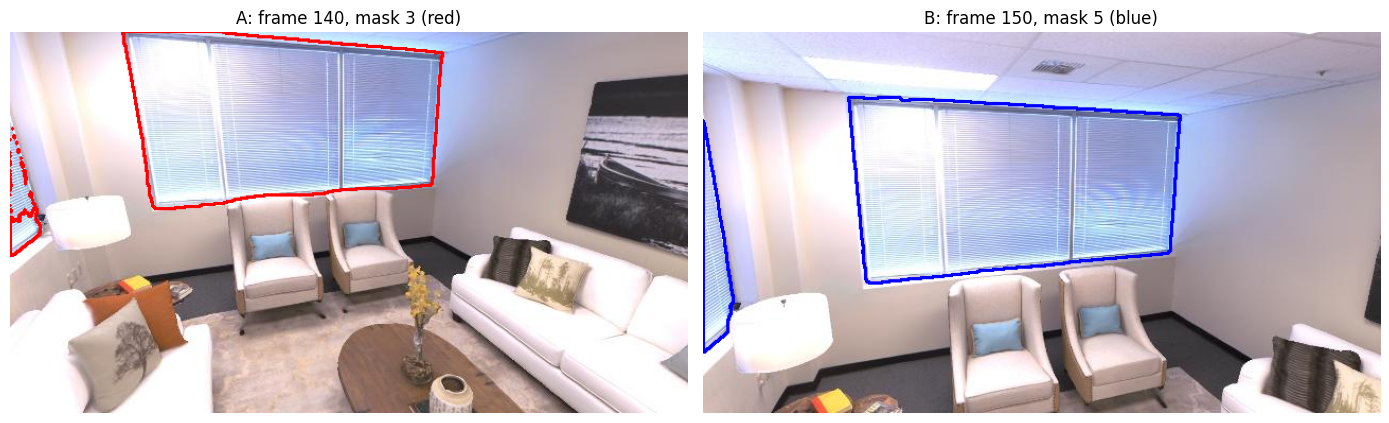

In [10]:
import matplotlib.pyplot as plt
from load_data import RenderedSample, load_frame_view

frame_view_a = load_frame_view(SCENE, frame_a, masks_root=str(MASKS_ROOT), rgb_root=str(RGB_ROOT))
frame_view_b = load_frame_view(SCENE, frame_b, masks_root=str(MASKS_ROOT), rgb_root=str(RGB_ROOT))

sample = RenderedSample(
    condition="pair_only",
    frame_a=frame_view_a,
    mask_id_a=mask_a,
    frame_b=frame_view_b,
    mask_id_b=mask_b,
    thickness=2,
)

images = sample.render()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(images[0])
axes[0].set_title(f"A: frame {frame_a}, mask {mask_a} (red)")
axes[0].axis("off")
axes[1].imshow(images[1])
axes[1].set_title(f"B: frame {frame_b}, mask {mask_b} (blue)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 5. Load Qwen3-VL-2B

This loads the model specified in `config_qwen3vl_2b.yaml`. If it was already cached, this should be faster than the first download.

In [11]:
import yaml
import torch
from vlm_utils import load_model

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

print("Config:", config)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model, processor = load_model(config)
print("Qwen model loaded")

INFO:vlm_utils:Using device: cuda
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-VL-2B-Instruct/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-VL-2B-Instruct/89644892e4d85e24eaac8bacfd4f463576704203/config.json "HTTP/1.1 200 OK"


Config: {'model_id': 'Qwen/Qwen3-VL-2B-Instruct', 'attn_implementation': 'sdpa', 'inference': {'max_new_tokens': 64}}
CUDA available: True
GPU: NVIDIA GeForce RTX 3090


INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-VL-2B-Instruct/resolve/main/model.safetensors "HTTP/1.1 302 Found"
Loading weights: 100%|███████████████████████████████████████████████████████████| 625/625 [00:01<00:00, 596.97it/s]
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-VL-2B-Instruct/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-VL-2B-Instruct/89644892e4d85e24eaac8bacfd4f463576704203/generation_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-VL-2B-Instruct/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/Qwen/Qwen3-VL-2B-Instruct/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen3-VL-2B-Instruct/89644892e4d85e24eaac8ba

Qwen model loaded


## 6. Run Qwen on this one pair

In [14]:
from inference import run_inference

prediction = run_inference(
    sample,
    model=model,
    processor=processor,
    max_new_tokens=int(config["inference"]["max_new_tokens"]),
)

print("decision  :", prediction["decision"], "(1=same object, 0=different)")
print("confidence:", prediction["confidence"])
print("reasoning :", prediction["reasoning"])

# Candidate edge score for the later graph: high only if Qwen predicts same instance.
if prediction["reasoning"] == "<parse error>":
    qwen_same_instance_score = 0.0
elif prediction["decision"] == 1:
    qwen_same_instance_score = float(prediction["confidence"])
else:
    qwen_same_instance_score = 0.0
print("qwen_same_instance_score:", qwen_same_instance_score)

decision  : 1 (1=same object, 0=different)
confidence: 0.95
reasoning : Both regions outline the same window with blinds, which is a single physical object in the scene.
qwen_same_instance_score: 0.95


## 7. Try a few more pairs manually

Change `candidate_row_idx` above, rerun cells 3, 4, and 6. Keep the model loaded; do not rerun cell 5 unless you restarted the kernel.

In [15]:
from pathlib import Path
import pandas as pd
from tqdm.auto import tqdm
from inference import run_inference
from load_data import RenderedSample, load_frame_view

N_PAIRS = 20

results = []
subset = candidates.sort_values("depth_iou", ascending=False).head(N_PAIRS).copy()

for idx, row in tqdm(subset.iterrows(), total=len(subset)):
    frame_a = int(row["frame_a"])
    mask_a = int(row["mask_a"])
    frame_b = int(row["frame_b"])
    mask_b = int(row["mask_b"])

    frame_view_a = load_frame_view(
        SCENE,
        frame_a,
        masks_root=str(MASKS_ROOT),
        rgb_root=str(RGB_ROOT),
    )
    frame_view_b = load_frame_view(
        SCENE,
        frame_b,
        masks_root=str(MASKS_ROOT),
        rgb_root=str(RGB_ROOT),
    )

    sample = RenderedSample(
        condition="pair_only",
        frame_a=frame_view_a,
        mask_id_a=mask_a,
        frame_b=frame_view_b,
        mask_id_b=mask_b,
        thickness=2,
    )

    prediction = run_inference(
        sample,
        model=model,
        processor=processor,
        max_new_tokens=int(config["inference"]["max_new_tokens"]),
    )

    if prediction["reasoning"] == "<parse error>":
        qwen_same_instance_score = 0.0
    elif prediction["decision"] == 1:
        qwen_same_instance_score = float(prediction["confidence"])
    else:
        qwen_same_instance_score = 0.0

    results.append({
        **row.to_dict(),
        "qwen_decision": int(prediction["decision"]),
        "qwen_confidence": float(prediction["confidence"]),
        "qwen_reasoning": prediction["reasoning"],
        "qwen_same_instance_score": qwen_same_instance_score,
    })

scores = pd.DataFrame(results)

OUT_DIR = REPO_ROOT / "Project" / "Milestone_3" / "data" / "qwen_scores"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = OUT_DIR / f"{SCENE}_qwen_scores_first_{N_PAIRS}.csv"
scores.to_csv(OUT_PATH, index=False)

print("Saved:", OUT_PATH)
display(scores)

100%|███████████████████████████████████████████████████████████████████████████████| 20/20 [00:18<00:00,  1.10it/s]

Saved: /rhome/flowis153/project/ML3D-VLM_based_2D_mask_grouping/Project/Milestone_3/data/qwen_scores/room0_qwen_scores_first_20.csv


,scene,frame_a,mask_a,frame_b,mask_b,global_mask_idx_a,global_mask_idx_b,points_a,points_b,points_intersection,...,num_observers,num_supporters,view_consensus_score,gt_instance_a,gt_instance_b,same_instance_label,qwen_decision,qwen_confidence,qwen_reasoning,qwen_same_instance_score
0,room0,140,3,150,5,253,274,39958,39677,39355,...,11.0,11.0,1.0,12019,12019,1,1,0.95,Region A and Region B both outline the same ph...,0.95
1,room0,60,17,70,20,109,129,13662,13704,13362,...,4.0,4.0,1.0,59063,59063,1,0,0.00,The two regions are not the same physical obje...,0.00
2,room0,20,8,30,9,36,52,6620,6530,6402,...,6.0,6.0,1.0,18002,18002,1,1,0.99,Both regions outline the same piece of furnitu...,0.99
3,room0,120,5,140,3,224,253,40373,39958,38800,...,11.0,11.0,1.0,12019,12019,1,1,0.95,Region A and Region B both outline the same la...,0.95
4,room0,120,5,150,5,224,274,40373,39677,38546,...,11.0,11.0,1.0,12019,12019,1,0,0.00,Region A and Region B are not the same physica...,0.00
5,room0,20,4,30,4,32,47,4937,4885,4724,...,4.0,4.0,1.0,47,47,1,1,0.95,Region A and Region B both outline the same wi...,0.95
6,room0,140,11,160,15,261,302,7154,7043,6815,...,11.0,11.0,1.0,20073,20073,1,1,0.95,Region A and Region B both outline the same pa...,0.95
7,room0,70,9,90,5,118,159,3647,3840,3576,...,3.0,3.0,1.0,47083,47083,1,1,0.95,Region A and Region B are both rectangular lig...,0.95
8,room0,10,6,20,8,22,36,6636,6620,6323,...,6.0,6.0,1.0,18002,18002,1,1,0.95,Both regions outline the same wooden console t...,0.95
9,room0,10,5,40,4,21,65,11829,12866,11758,...,6.0,6.0,1.0,37036,37036,1,1,0.99,"The two regions are the same physical object, ...",0.99
